In [1]:
import sys
if "vision_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

环境配置正常


In [2]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import cv2

print("opencv:", cv2.__version__)
print("numpy:", np.__version__)

opencv: 4.13.0
numpy: 2.2.5


<font color = #000000 >

## 3. 阈值与平滑处理
</font>


In [3]:
picture = '../Pictures/'
# 定义图像展示函数
def img_show(img):
    if img is None:
        print("图像读取失败")
    else:
        # 图像展示
        cv2.imshow("image", img)    # 首先需要确定图像存在才能打开
        print(img.shape)
        cv2.waitKey(0)  # 等待时间,0对应无限等待,知道按下任意按键
        cv2.destroyAllWindows() 

(414, 500)

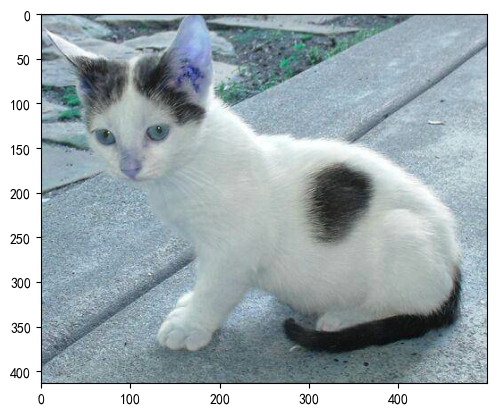

In [4]:
img=cv2.imread(picture + 'cat.jpg')
plt.imshow(img)
img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img_gray.shape

<font color = #000000>

### 3-1 图像阈值

**ret, dst = cv2.threshold(src, thresh, maxval, type)**

- src： 输入图，只能输入单通道图像，通常来说为灰度图
- dst： 输出图
- thresh： 阈值
- maxval： 当像素值超过了阈值（或者小于阈值，根据type来决定），所赋予的值
- type：二值化操作的类型，包含以下5种类型： cv2.THRESH_BINARY； cv2.THRESH_BINARY_INV； cv2.THRESH_TRUNC； cv2.THRESH_TOZERO；cv2.THRESH_TOZERO_INV

- cv2.THRESH_BINARY           超过阈值部分取maxval（最大值），否则取0
- cv2.THRESH_BINARY_INV    THRESH_BINARY的反转
- cv2.THRESH_TRUNC            大于阈值部分设为阈值，否则不变
- cv2.THRESH_TOZERO          大于阈值部分不改变，否则设为0
- cv2.THRESH_TOZERO_INV  THRESH_TOZERO的反转
</font> 


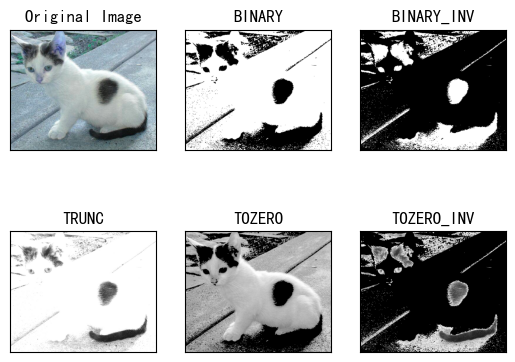

In [5]:
ret, thresh1 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
ret, thresh2 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY_INV)
ret, thresh3 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_TRUNC)
ret, thresh4 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_TOZERO)
ret, thresh5 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_TOZERO_INV)

titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

for i in range(6):
    plt.subplot(2, 3, i + 1), plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()

<font color = #000000>

### 3-2 图像平滑处理
- 均值滤波
- 方框滤波
- 方框滤波-归一化
- 高斯滤波
- 中值滤波
</font>

In [6]:
img = cv2.imread(picture + 'lenaNoise.png')
img_show(img)

(512, 512, 3)


<font color = #000000>

#### 3-2-1 均值滤波
+ ksize:卷积核（Kernel）大小,也叫 滤波窗口大小,所以每次计算一个像素时，会取周围 n × n 个像素

| 核大小   | 效果   |
| ----- | ---- |
| (3,3) | 轻微平滑 |
| (5,5) | 中等平滑 |
| (9,9) | 很强平滑 |

</font>

In [7]:
# 均值滤波
blur = cv2.blur(img , (3,3))    # 3x3更新
img_show(blur)

(512, 512, 3)


<font color = #000000>

#### 3-2-2 方框滤波

| 参数          | 含义      |
| ----------- | ------- |
| `src`       | 输入图像    |
| `ddepth`    | 输出图像的深度 |
| `ksize`     | 卷积核大小   |
| `normalize` | 是否归一化   |

+ normalize : 是否归一化: 如果是的话那么和均值滤波没区别,不归一化就直接相加

</font>

In [8]:
# 方框滤波-归一化
box = cv2.boxFilter(img,-1,(3,3), normalize=True)  
img_show(box)

(512, 512, 3)


In [9]:
# 方框滤波-不归一化
box = cv2.boxFilter(img,-1,(3,3), normalize=False)  
img_show(box)

(512, 512, 3)


<font color = #000000>

#### 3-2-3 高斯滤波

**高斯模糊的卷积核里的数值是满足高斯分布，相当于更重视中间的**

</font>


In [10]:
# 高斯滤波
aussian = cv2.GaussianBlur(img, (5, 5), 1)  
img_show(aussian)

(512, 512, 3)


<font color = #000000>

#### 3-2-4 中值滤波

**相当于用中值代替**

</font>


In [11]:
# 中值滤波
median = cv2.medianBlur(img, 3)  # 中值滤波更容易跳过噪点(因为噪点的值比较极端,不容易在中值)
img_show(median)

(512, 512, 3)


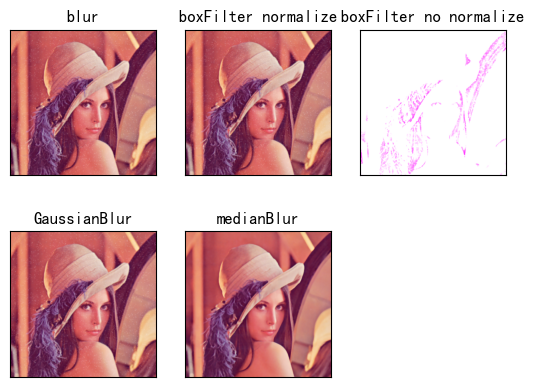

In [12]:
# 总览
titles = ['blur','boxFilter normalize','boxFilter no normalize','GaussianBlur','medianBlur']

images = []

images.append(  cv2.blur(img,(3,3))  )
images.append(  cv2.boxFilter(img,-1,(3,3),normalize=True)  )
images.append(  cv2.boxFilter(img,-1,(3,3),normalize=False)  )
images.append(  cv2.GaussianBlur(img,(5,5),1)  )
images.append(  cv2.medianBlur(img,5)  )

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.xticks([])
    plt.yticks([])

plt.show()

In [13]:
# 并列总览
res = np.hstack((blur,aussian,median))  # 还有vstack:竖着展示
img_show(res)

(512, 1536, 3)


<font color = #000000>

### 参考格式
</font>